In [32]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

In [33]:
credit= pd.read_csv('creditcard.csv')
credit

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


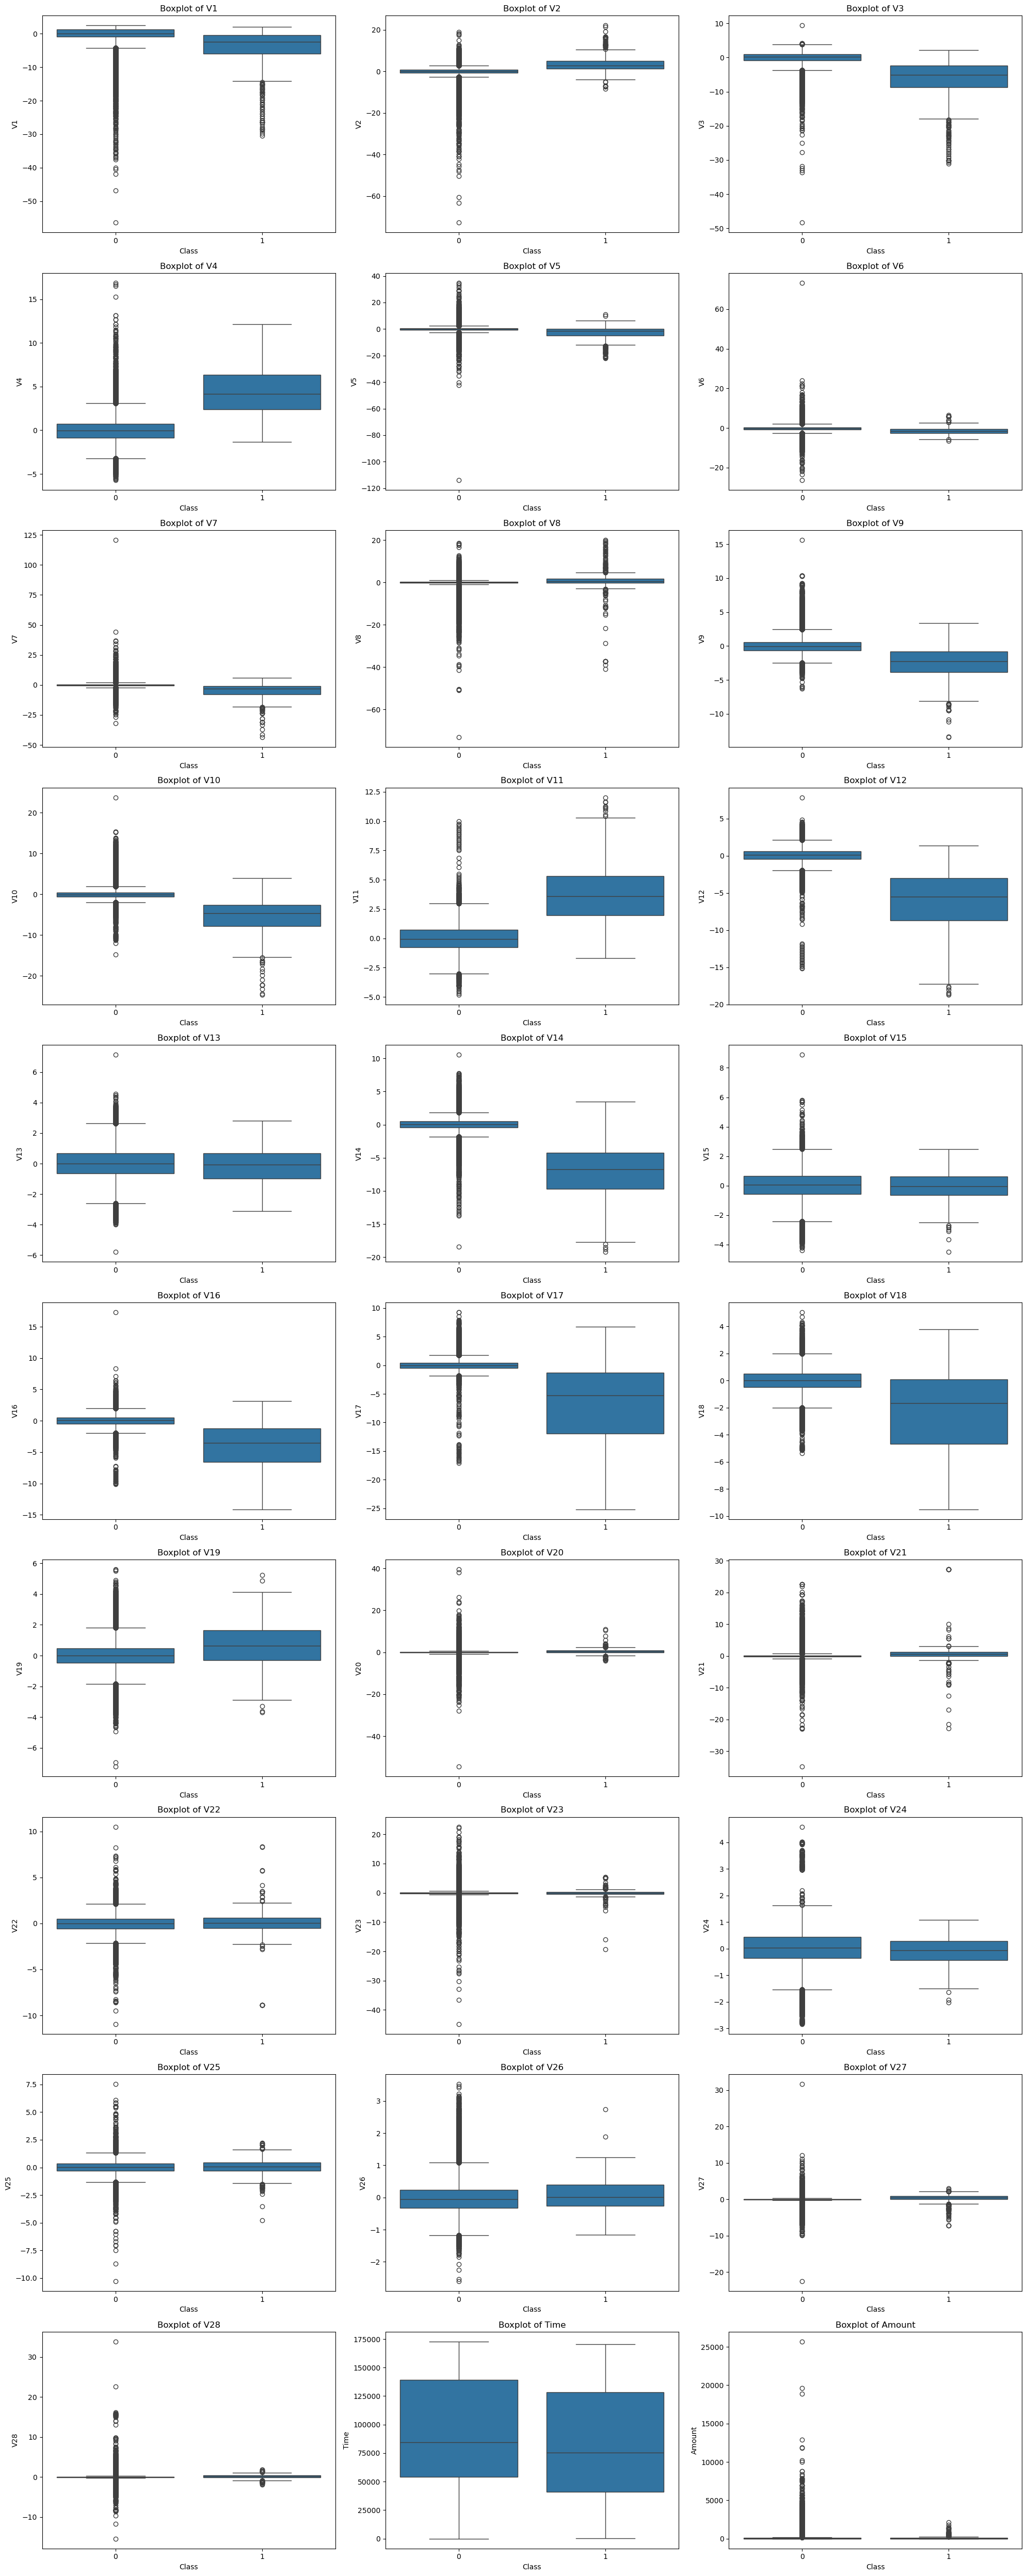

In [34]:
#Q1
features = [f'V{i}' for i in range(1, 29)] + ['Time', 'Amount']

plt.figure(figsize=(20, 50)) 
for i, col in enumerate(features):
    plt.subplot(10, 3, i+1) 
    sns.boxplot(x='Class', y=col, data=credit) 
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [35]:

#- V1, V3, V9, V10, V12, V14, V16, V17, V18 
#정상거래(0) 데이터의 분포가 불량 거래(1)데이터의 분포에 비해 높게 형성되어 있음 
#해당 변수들은 목표변수와 음의 상관관계
#데이터 값이 증가할 수록 목표 변수가 0(정상거래)일 확률이 높다.
#- V2, V4, V11
#정상거래(0) 데이터의 분포가 불량 거래(1)데이터의 분포에 비해 낮게 형성되어 있음
#해당 변수들은 목표변수와 양의 상관관계
#데이터 값이 증가할 수록 목표 변수가 1(불량거래)일 확률이 높다.
#- V5, V6, V7, V8, V13, V15, V19, V20, V21, V22, V23, V24, V25, V26, V27, V28, Time, Amount
#정상거래, 불량거래 데이터의 분포가 비슷함
#두 범주 간의 중앙값과 사분위수 범위가 중첩되는 부분이 많음.
#해당 변수들의 값으로 불량 거래를 파악하기 어려움.


In [36]:
#Q2
quartiles = credit[features].describe().loc[['25%', '50%', '75%']]
print(quartiles)

           V1        V2        V3        V4        V5        V6        V7  \
25% -0.920373 -0.598550 -0.890365 -0.848640 -0.691597 -0.768296 -0.554076   
50%  0.018109  0.065486  0.179846 -0.019847 -0.054336 -0.274187  0.040103   
75%  1.315642  0.803724  1.027196  0.743341  0.611926  0.398565  0.570436   

           V8        V9       V10  ...       V21       V22       V23  \
25% -0.208630 -0.643098 -0.535426  ... -0.228395 -0.542350 -0.161846   
50%  0.022358 -0.051429 -0.092917  ... -0.029450  0.006782 -0.011193   
75%  0.327346  0.597139  0.453923  ...  0.186377  0.528554  0.147642   

          V24       V25       V26       V27       V28      Time  Amount  
25% -0.354586 -0.317145 -0.326984 -0.070840 -0.052960   54201.5   5.600  
50%  0.040976  0.016594 -0.052139  0.001342  0.011244   84692.0  22.000  
75%  0.439527  0.350716  0.240952  0.091045  0.078280  139320.5  77.165  

[3 rows x 30 columns]


In [37]:
#Q3
features = ['V1','V2','V3','V4','V5','V6','V7','V8','V9','V10',
            'V11','V12','V13','V14','V15','V16','V17','V18','V19','V20',
            'V21','V22','V23','V24','V25','V26','V27','V28','Time','Amount']

selected = features.copy()
step = 1

while True:
    formula = 'Class ~ ' + ' + '.join(selected)
    model = smf.logit(formula=formula, data=credit).fit(disp=0)
    
    pvalues = model.pvalues.drop('Intercept')
    max_pval = pvalues.max()
    max_var = pvalues.idxmax()
    
    if max_pval > 0.05:
        selected.remove(max_var)
        print(f"{max_var}")
        step += 1
    else:
        break



V18
V26
V2
V3
V17
V25
V11
V24
V12
V19
V15
Time
V6


In [38]:
credit.logistic = smf.logit(formula=formula,data=credit).fit()
credit.logistic.summary()

Optimization terminated successfully.
         Current function value: 0.003933
         Iterations 13


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Class   No. Observations:               284807
Model:                          Logit   Df Residuals:                   284789
Method:                           MLE   Df Model:                           17
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                  0.6907
Time:                        01:16:15   Log-Likelihood:                -1120.2
converged:                       True   LL-Null:                       -3621.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -8.6542      0.132    -65.366      0.000      -8.914      -8.395
V1             0.0786      0.036      2.197      0.028       0.008       0.149
V4             0.6800      0.061     11.141      0.000       0.560       0.800
V5             0.1410      0.031      4.534      0.000       0.080       0.202
V7            -0.1183      0.056     -2.126      0.033      -0.227      -0.009
V8            -0.1489      0.023     -6.590      0.000      -0.193      -0.105
V9            -0.2229      0.083     -2.682      0.007      -0.386      -0.060
V10           -0.7746      0.086     -8.983      0.000      -0.944      -0.606
V13           -0.3031      0.079     -3.860      0.000      -0.457      -0.149
V14           -0.5128      0.051    -10.010      0.000      -0.613      -0.412
V16           -0.2351      0.060     -3.908      0.000      -0.353      -0.117
V20           -0.4104      0.076     -5.419      0.000      -0.559      -0.262
V21            0.3615      0.054      6.747      0.000       0.256       0.466
V22            0.5685      0.123      4.612      0.000       0.327       0.810
V23           -0.1057      0.052     -2.050      0.040      -0.207      -0.005
V27           -0.7429      0.122     -6.067      0.000      -0.983      -0.503
V28           -0.2780      0.091     -3.060      0.002      -0.456      -0.100
Amount         0.0008      0.000      2.644      0.008       0.000       0.001
==============================================================================

Possibly complete quasi-separation: A fraction 0.29 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


selected_features = ['V1', 'V4', 'V5', 'V7', 'V8', 'V9', 'V10', 'V13', 'V14', 'V16', 'V20', 'V21', 'V22', 'V23', 'V27', 'V28', 'Amount']
X = credit[selected_features]
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data.sort_values(by="VIF", ascending=False))

   feature       VIF
16  Amount  1.913772
3       V7  1.268589
2       V5  1.253982
10     V20  1.196001
0       V1  1.088224
13     V23  1.021585
11     V21  1.019117
4       V8  1.018079
6      V10  1.017530
1       V4  1.016586
12     V22  1.007145
5       V9  1.003331
8      V14  1.001938
14     V27  1.001414
15     V28  1.000179
7      V13  1.000048
9      V16  1.000026


In [40]:
result = pd.DataFrame({'Coefficient': credit.logistic.params,'P-value': credit.logistic.pvalues})
print(result)

           Coefficient       P-value
Intercept    -8.654246  0.000000e+00
V1            0.078614  2.803819e-02
V4            0.680046  7.911720e-29
V5            0.141035  5.777504e-06
V7           -0.118337  3.347882e-02
V8           -0.148922  4.405734e-11
V9           -0.222868  7.316852e-03
V10          -0.774561  2.629663e-19
V13          -0.303063  1.135345e-04
V14          -0.512850  1.370915e-23
V16          -0.235062  9.305538e-05
V20          -0.410433  5.978567e-08
V21           0.361457  1.513738e-11
V22           0.568478  3.986886e-06
V23          -0.105665  4.041068e-02
V27          -0.742866  1.302552e-09
V28          -0.277978  2.215809e-03
Amount        0.000758  8.185719e-03


In [41]:
'''
Q4
1. boxplot 결과와 일치하는 경우 (양의 상관관계)
V4
2. boxplot 결과와 일치하는 경우 (음의 상관관계)
V9, V10, V14, V16,
3. boxplot 결과와 일치하는 경우 (영향 미비)
V6, V15, V19, V24, V25, V26, Time
4. boxplot 결과와 일치하지 않는 경우
- V1: boxplot 분석 결과 목표 변수와 음의 상관관계를 보일 것으로 예상했으나, 회귀계수가 (+)로 양의 상관관계를 보임.
-V5, V21, V22, Amount : boxplot 결과에서 목표 변수 범주별 데이터의 분포가 육안으로 크게 차이 나지 않았으나, 로지스틱 회귀분석 결과 유의확률이 0.05보다 작으며, 회귀계수가 (+)임.
-V7, V8, V13, V20, V23, V27, V28: boxplot 결과에서 목표 변수 범주별 데이터의 분포가 육안으로 크게 차이 나지 않았으나, 로지스틱 회귀분석 결과 유의확률이 0.05보다 작으며, 회귀계수가 (-)임.
-V2, V11: boxplot 분석 결과 목표 변수와 양의 상관관계를 보일 것으로 예상했으나, 유의확률이 0.05보다 크게 나타남.
- V3, V12, V17, V18: boxplot 분석 결과 목표 변수와 음의 상관관계를 보일 것으로 예상했으나, 유의확률이 0.05보다 크게 나타남.
'''

'\nQ4\n1. boxplot 결과와 일치하는 경우 (양의 상관관계)\nV4\n2. boxplot 결과와 일치하는 경우 (음의 상관관계)\nV9, V10, V14, V16,\n3. boxplot 결과와 일치하는 경우 (영향 미비)\nV6, V15, V19, V24, V25, V26, Time\n4. boxplot 결과와 일치하지 않는 경우\n- V1: boxplot 분석 결과 목표 변수와 음의 상관관계를 보일 것으로 예상했으나, 회귀계수가 (+)로 양의 상관관계를 보임.\n-V5, V21, V22, Amount : boxplot 결과에서 목표 변수 범주별 데이터의 분포가 육안으로 크게 차이 나지 않았으나, 로지스틱 회귀분석 결과 유의확률이 0.05보다 작으며, 회귀계수가 (+)임.\n-V7, V8, V13, V20, V23, V27, V28: boxplot 결과에서 목표 변수 범주별 데이터의 분포가 육안으로 크게 차이 나지 않았으나, 로지스틱 회귀분석 결과 유의확률이 0.05보다 작으며, 회귀계수가 (-)임.\n-V2, V11: boxplot 분석 결과 목표 변수와 양의 상관관계를 보일 것으로 예상했으나, 유의확률이 0.05보다 크게 나타남.\n- V3, V12, V17, V18: boxplot 분석 결과 목표 변수와 음의 상관관계를 보일 것으로 예상했으나, 유의확률이 0.05보다 크게 나타남.\n'

In [42]:
#Q5
np.exp(credit.logistic.params)

Intercept    0.000174
V1           1.081787
V4           1.973969
V5           1.151465
V7           0.888397
V8           0.861637
V9           0.800221
V10          0.460906
V13          0.738553
V14          0.598787
V16          0.790522
V20          0.663363
V21          1.435419
V22          1.765577
V23          0.899726
V27          0.475748
V28          0.757314
Amount       1.000759
dtype: float64

In [43]:
'''
Q5
V1가 1 증가하면 불량 사용의 가능성은 1.08배로 증가한다.
V4가 1 증가하면 불량 사용의 가능성은 1.97배로 증가한다.
V5가 1 증가하면 불량 사용의 가능성은 1.15배로 증가한다.
V7이 1 증가하면 불량 사용의 가능성은 0.89배가 된다.
V8이 1 증가하면 불량 사용의 가능성은 0.83배가 된다.
V9가 1 증가하면 불량 사용의 가능성은 0.80배가 된다.
V10이 1 증가하면 불량 사용의 가능성은 0.46배가 된다.
V13이 1 증가하면 불량 사용의 가능성은 0.74배가 된다.
V14가 1 증가하면 불량 사용의 가능성은 0.60배가 된다.
V16이 1 증가하면 불량 사용의 가능성은 0.79배가 된다.
V20이 1 증가하면 불량 사용의 가능성은 0.66배가 된다.
V21이 1 증가하면 불량 사용의 가능성은 1.44배로 증가한다.
V22가 1 증가하면 불량 사용의 가능성은 1.77배로 증가한다.
V23이 1 증가하면 불량 사용의 가능성은 0.90배가 된다.
V27이 1 증가하면 불량 사용의 가능성은 0.48배가 된다.
V28이 1 증가하면 불량 사용의 가능성은 0.76배가 된다.
'''

'\nQ5\nV1가 1 증가하면 불량 사용의 가능성은 1.08배로 증가한다.\nV4가 1 증가하면 불량 사용의 가능성은 1.97배로 증가한다.\nV5가 1 증가하면 불량 사용의 가능성은 1.15배로 증가한다.\nV7이 1 증가하면 불량 사용의 가능성은 0.89배가 된다.\nV8이 1 증가하면 불량 사용의 가능성은 0.83배가 된다.\nV9가 1 증가하면 불량 사용의 가능성은 0.80배가 된다.\nV10이 1 증가하면 불량 사용의 가능성은 0.46배가 된다.\nV13이 1 증가하면 불량 사용의 가능성은 0.74배가 된다.\nV14가 1 증가하면 불량 사용의 가능성은 0.60배가 된다.\nV16이 1 증가하면 불량 사용의 가능성은 0.79배가 된다.\nV20이 1 증가하면 불량 사용의 가능성은 0.66배가 된다.\nV21이 1 증가하면 불량 사용의 가능성은 1.44배로 증가한다.\nV22가 1 증가하면 불량 사용의 가능성은 1.77배로 증가한다.\nV23이 1 증가하면 불량 사용의 가능성은 0.90배가 된다.\nV27이 1 증가하면 불량 사용의 가능성은 0.48배가 된다.\nV28이 1 증가하면 불량 사용의 가능성은 0.76배가 된다.\n'

In [44]:
#Q6
V = ['V1','V4','V5','V7','V8','V9','V10','V13','V14','V16','V20','V21','V22','V23','V27','V28','Amount']
q3_values = credit[V].quantile(0.75)

test_data = pd.DataFrame([q3_values])


probability = credit.logistic.predict(test_data)
probability

0.75    0.000141
dtype: float64